In [ ]:
# !pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

In [3]:
# Import necessay libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.concat([X,y],axis =1)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Data Exploration and Preprocessing

Perform Data wrangling and EDA

In [5]:
# Dataset Shape
df.shape

(48842, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
# Check for Missing Values
df.isnull().sum()

,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


In [8]:
# Drop rows with missing values
df.dropna(inplace=True)

In [9]:
# Check for empty
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [10]:
print('\nBasic Statistics:')
print(df.describe())


Basic Statistics:
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  47621.000000  4.762100e+04   47621.000000  47621.000000  47621.000000   
mean      38.640684  1.897271e+05      10.090821   1091.137649     87.853489   
std       13.558961  1.055695e+05       2.568320   7487.228336    404.010612   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175840e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.782820e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.377200e+05      12.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    47621.000000  
mean        40.600050  
std         12.260345  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


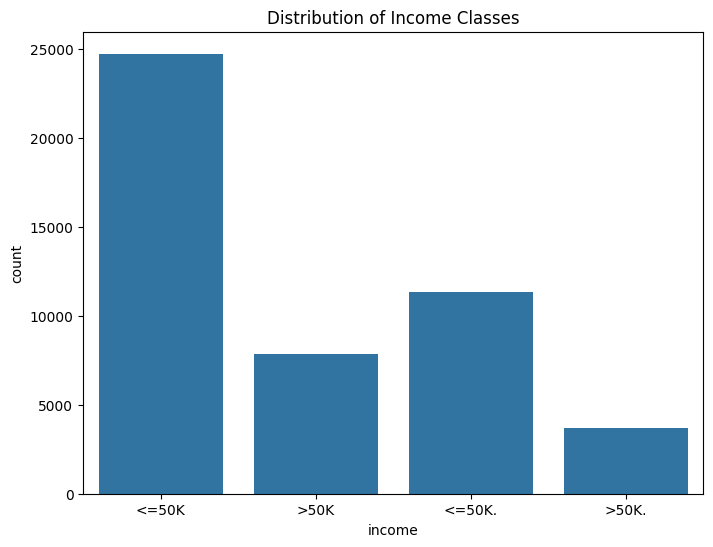

In [11]:
# Visualize target distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='income')
plt.title('Distribution of Income Classes')
plt.show()

In [12]:
# Clean income values by removing periods
df['income'] = df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

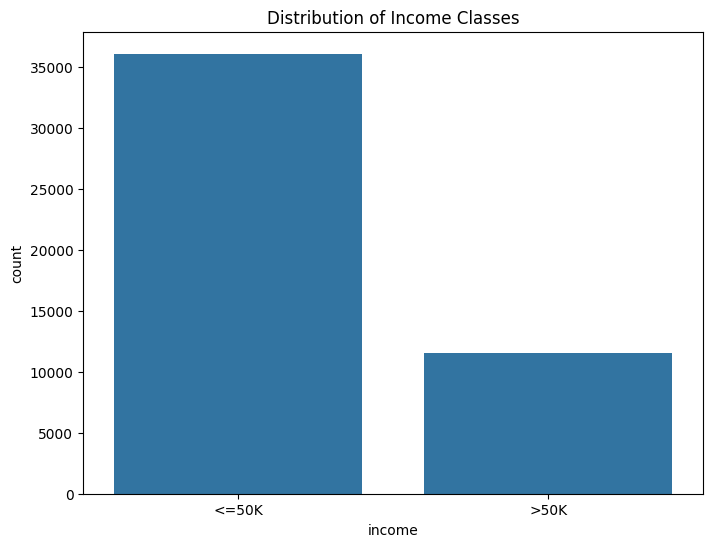

In [13]:
# Visualize target distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='income')
plt.title('Distribution of Income Classes')
plt.show()

In [14]:
# Identify categorical and numerical columns
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Display unique values in categorical columns
print('Categorical columns unique values:')
for col in cat_cols:
    print(df[col].value_counts())

Categorical columns unique values:
workclass
Private             33717
Self-emp-not-inc     3838
Local-gov            3126
State-gov            1965
?                    1836
Self-emp-inc         1688
Federal-gov          1423
Without-pay            21
Never-worked            7
Name: count, dtype: int64
education
HS-grad         15444
Some-college    10512
Bachelors        7881
Masters          2610
Assoc-voc        2034
11th             1746
Assoc-acdm       1566
10th             1336
7th-8th           912
Prof-school       819
9th               735
12th              633
Doctorate         582
5th-6th           494
1st-4th           239
Preschool          78
Name: count, dtype: int64
marital-status
Married-civ-spouse       21966
Never-married            15555
Divorced                  6526
Separated                 1497
Widowed                   1443
Married-spouse-absent      600
Married-AF-spouse           34
Name: count, dtype: int64
occupation
Prof-specialty       6110
Craft-repair

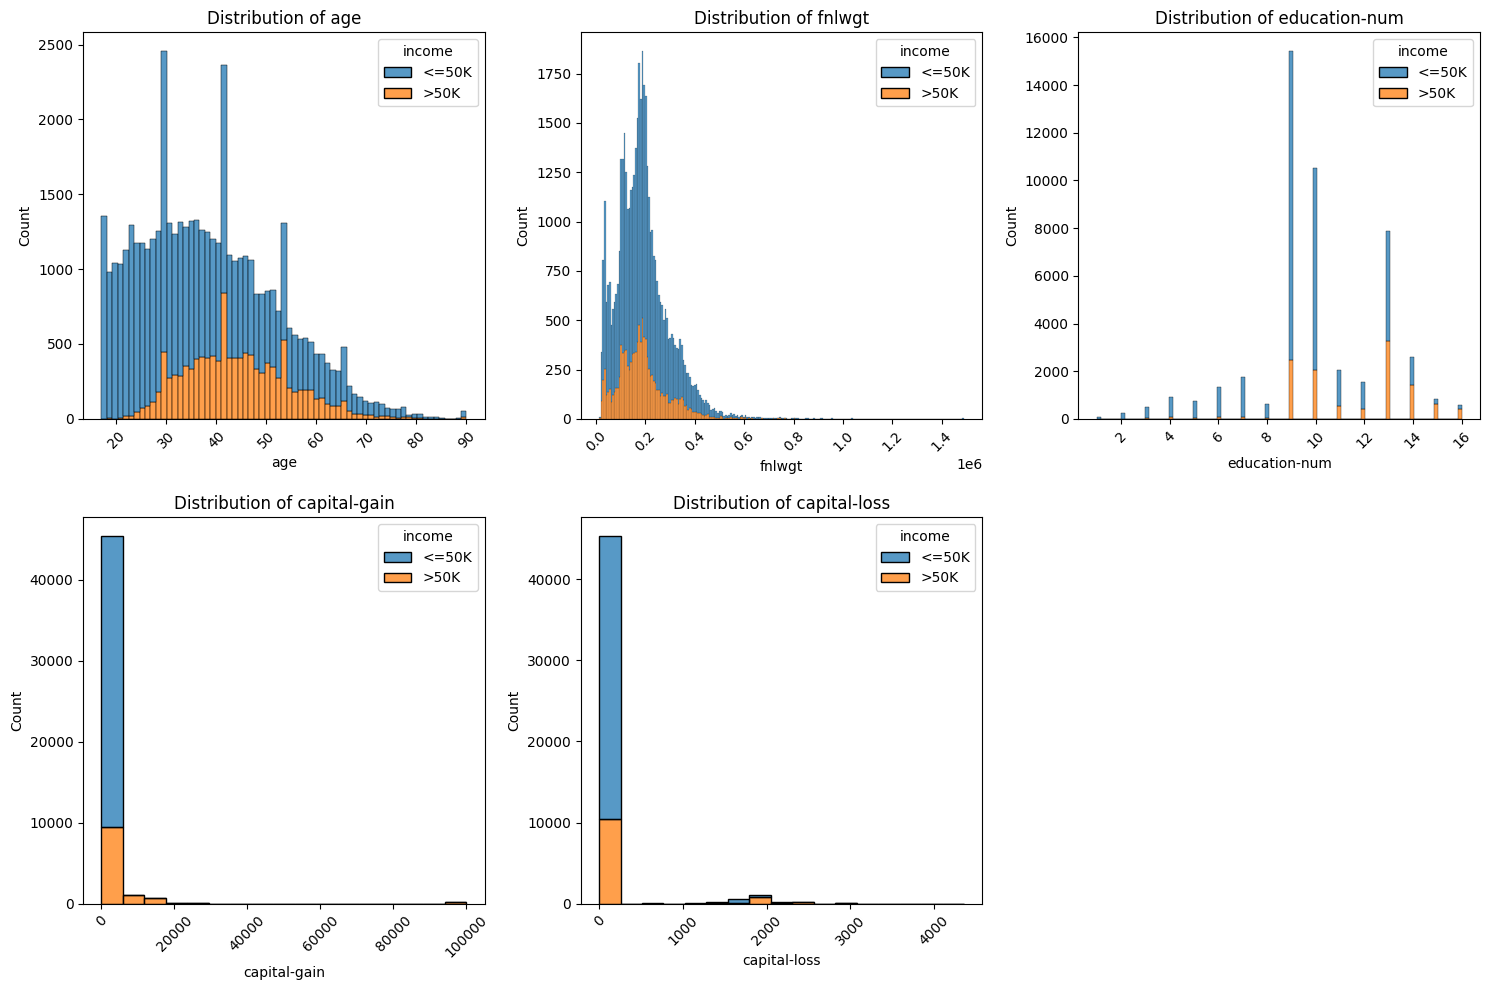

In [15]:
# Visualize distributions of numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:-1], 1):  # Excluding the target variable
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='income', multiple="stack")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

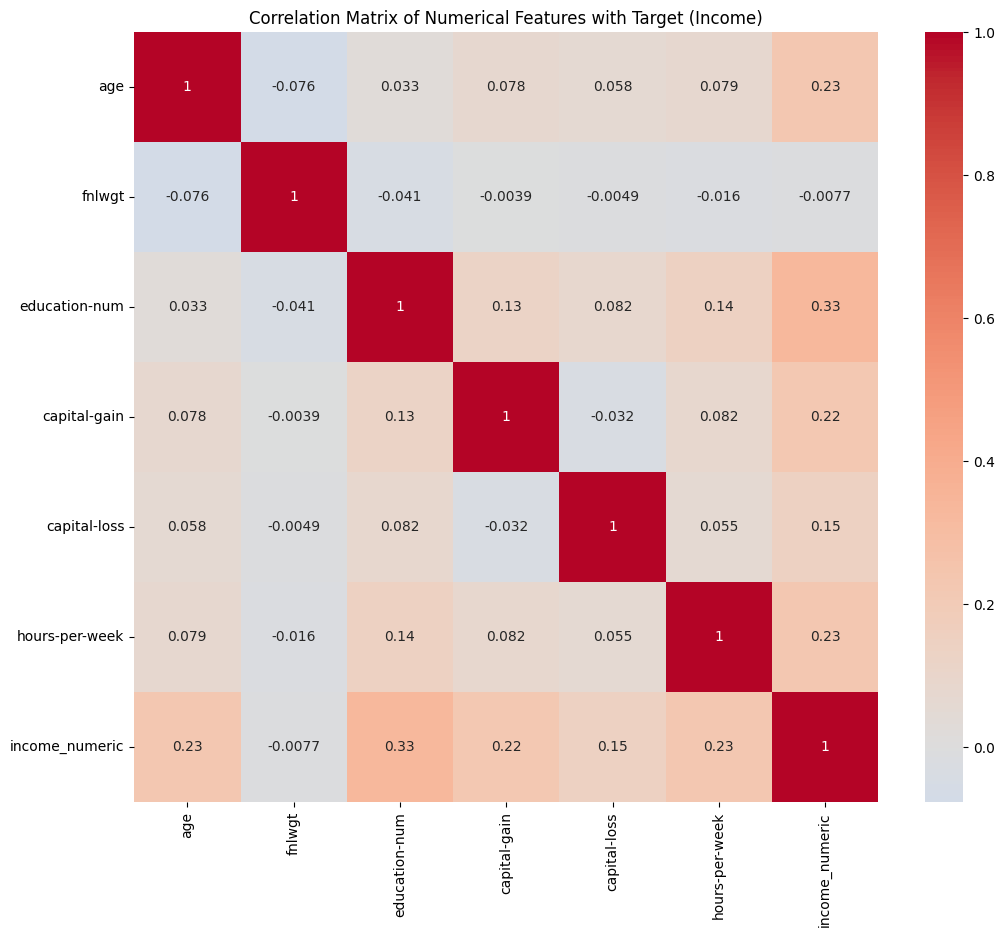

In [16]:
# Correlation analysis including target variable
# Convert target to numeric for correlation analysis
df['income_numeric'] = (df['income'] == '>50K').astype(int)

# Include income in correlation analysis
correlation_data = df[list(num_cols) + ['income_numeric']]
plt.figure(figsize=(12, 10))
correlation_matrix = correlation_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features with Target (Income)')
plt.show()

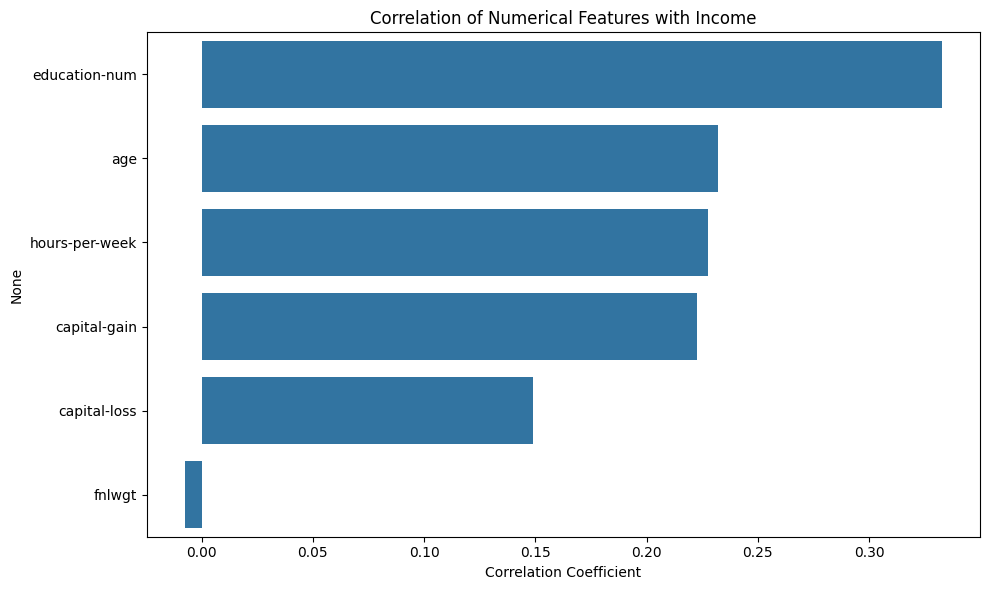

In [17]:
# Display correlation with target specifically
income_correlations = correlation_matrix['income_numeric'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=income_correlations.values[1:], y=income_correlations.index[1:])
plt.title('Correlation of Numerical Features with Income')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('income_numeric', axis=1, inplace=True)

In [18]:
low_correlation_features = ['fnlwgt']
df = df.drop(columns=low_correlation_features)

print('\nRemaining features:', (df.columns))


Remaining features: Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')


### Data Preprocessing

Handling categorical variables and scaling numerical features.

In [19]:
# Create copy of the dataframe
df_processed = df.copy()

# Label Encoding for categorical variables
le = LabelEncoder()
for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Separate features and target
X = df_processed.drop('income', axis=1)
y = df_processed['income']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set shape:', X_train_scaled.shape)
print('Testing set shape:', X_test_scaled.shape)

Training set shape: (38096, 13)
Testing set shape: (9525, 13)


In [20]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Print classification report
    print(f'\nClassification Report - {model_name}')
    print(classification_report(y_test, y_pred))

    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f'\nCross-validation scores: {cv_scores}')
    print(f'Average CV score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

    return accuracy

### 1. K-Nearest Neighbors (KNN)
Implementation and evaluate of the KNN classifier with different values of k.

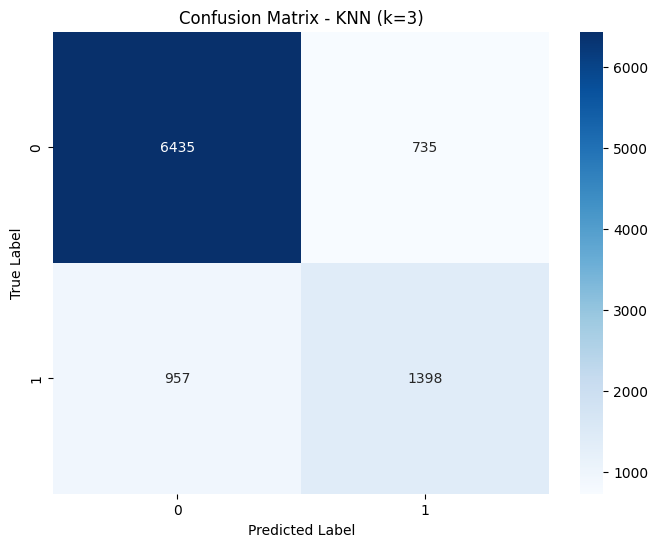


Classification Report - KNN (k=3)
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      7170
           1       0.66      0.59      0.62      2355

    accuracy                           0.82      9525
   macro avg       0.76      0.75      0.75      9525
weighted avg       0.82      0.82      0.82      9525


Cross-validation scores: [0.82362205 0.81769261 0.82871768 0.82478015 0.82583016]
Average CV score: 0.824 (+/- 0.007)


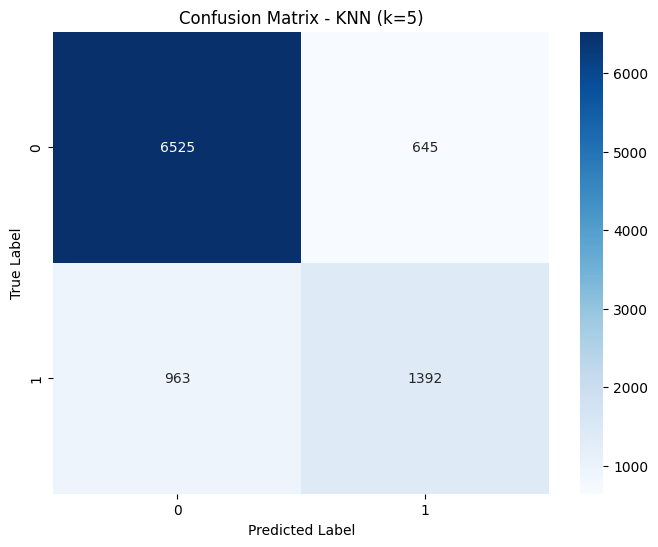


Classification Report - KNN (k=5)
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      7170
           1       0.68      0.59      0.63      2355

    accuracy                           0.83      9525
   macro avg       0.78      0.75      0.76      9525
weighted avg       0.82      0.83      0.83      9525


Cross-validation scores: [0.8339895  0.83094894 0.83081769 0.82976769 0.83291771]
Average CV score: 0.832 (+/- 0.003)


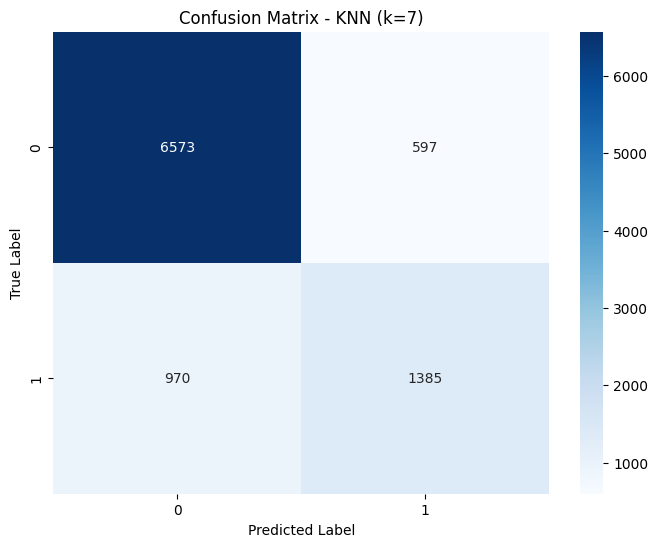


Classification Report - KNN (k=7)
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      7170
           1       0.70      0.59      0.64      2355

    accuracy                           0.84      9525
   macro avg       0.79      0.75      0.77      9525
weighted avg       0.83      0.84      0.83      9525


Cross-validation scores: [0.8343832  0.83016144 0.8318677  0.83108019 0.83606773]
Average CV score: 0.833 (+/- 0.004)


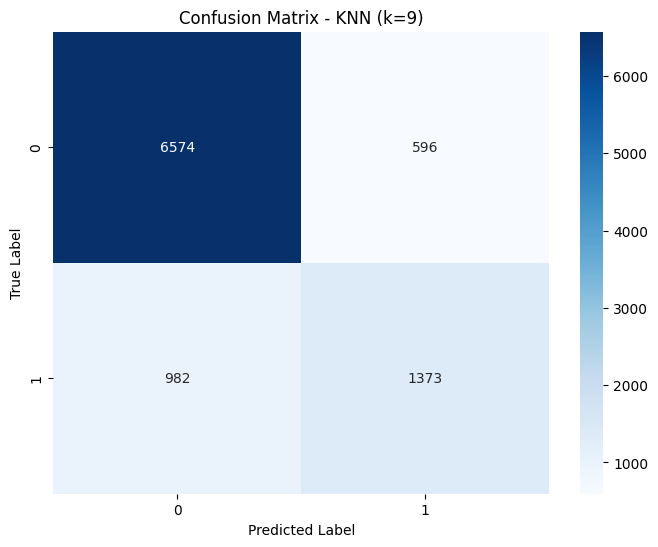


Classification Report - KNN (k=9)
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      7170
           1       0.70      0.58      0.64      2355

    accuracy                           0.83      9525
   macro avg       0.78      0.75      0.76      9525
weighted avg       0.83      0.83      0.83      9525


Cross-validation scores: [0.8343832  0.83580522 0.8318677  0.8313427  0.83921775]
Average CV score: 0.835 (+/- 0.006)


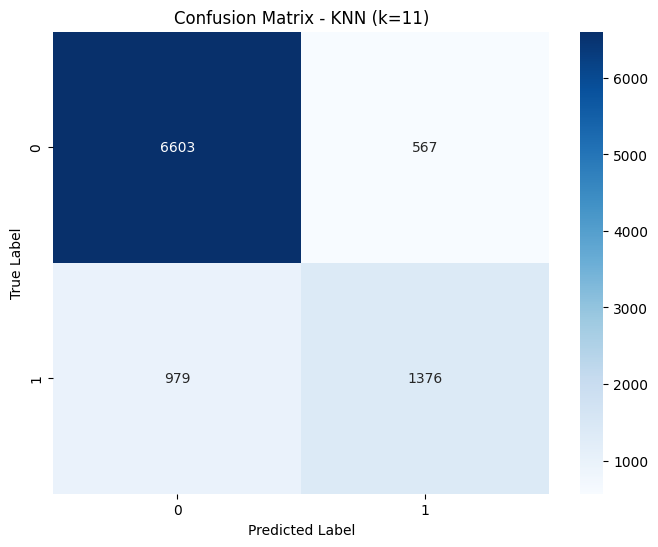


Classification Report - KNN (k=11)
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      7170
           1       0.71      0.58      0.64      2355

    accuracy                           0.84      9525
   macro avg       0.79      0.75      0.77      9525
weighted avg       0.83      0.84      0.83      9525


Cross-validation scores: [0.83425197 0.8326552  0.83475522 0.83449272 0.84236776]
Average CV score: 0.836 (+/- 0.007)


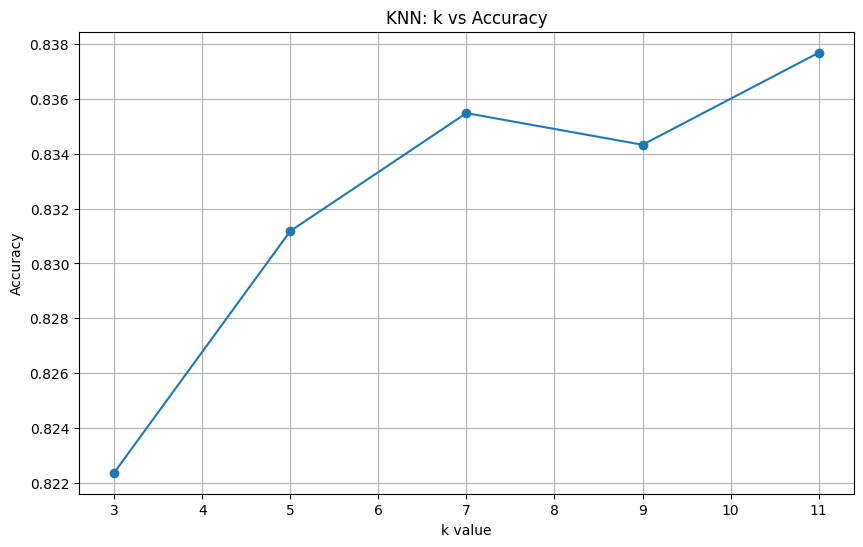

In [21]:
from sklearn.neighbors import KNeighborsClassifier

# Test different values of k
k_values = [3, 5, 7, 9, 11]
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    accuracy = evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test, f'KNN (k={k})')
    knn_scores.append(accuracy)

# Plot k values vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_scores, marker='o')
plt.title('KNN: k vs Accuracy')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### 2. Support Vector Machines (SVM)
Implemention of SVM with different kernels.

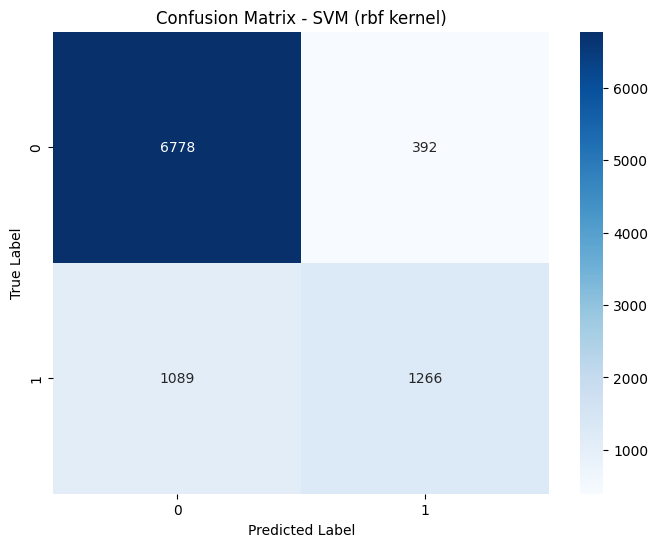


Classification Report - SVM (rbf kernel)
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      7170
           1       0.76      0.54      0.63      2355

    accuracy                           0.84      9525
   macro avg       0.81      0.74      0.77      9525
weighted avg       0.84      0.84      0.83      9525


Cross-validation scores: [0.84619423 0.8473553  0.84958656 0.8476178  0.85418034]
Average CV score: 0.849 (+/- 0.006)


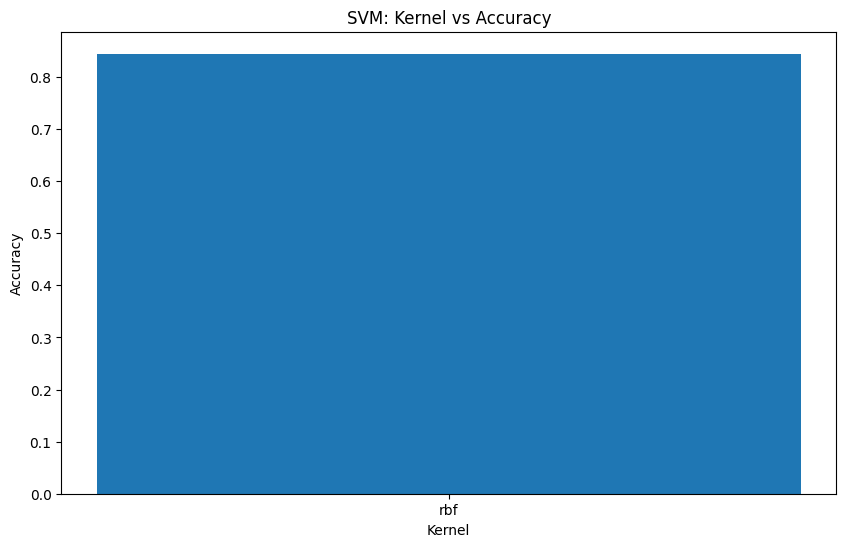

In [31]:
from sklearn.svm import SVC

# Test different kernels
# kernels = ['linear', 'rbf', 'poly']
kernels = ['rbf']
svm_scores = []

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    accuracy = evaluate_model(svm, X_train_scaled, X_test_scaled, y_train, y_test, f'SVM ({kernel} kernel)')
    svm_scores.append(accuracy)

# Plot kernel vs accuracy
plt.figure(figsize=(10, 6))
plt.bar(kernels, svm_scores)
plt.title('SVM: Kernel vs Accuracy')
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.show()

### 3. Decision Trees
Implementation and visualize of Decision Tree classifier.

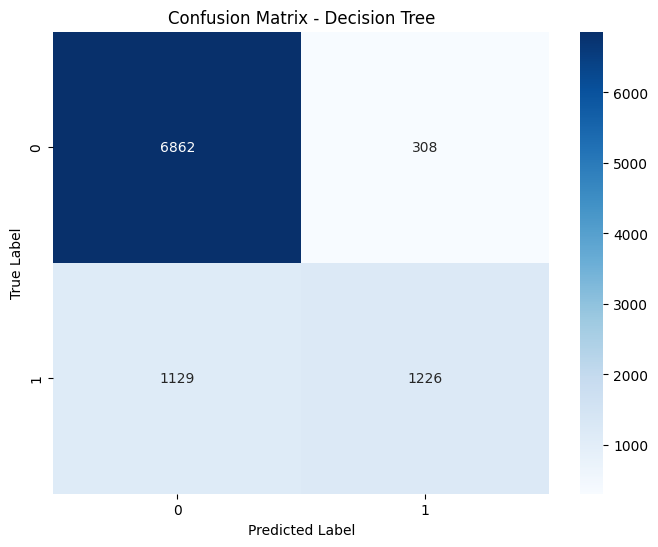


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      7170
           1       0.80      0.52      0.63      2355

    accuracy                           0.85      9525
   macro avg       0.83      0.74      0.77      9525
weighted avg       0.84      0.85      0.84      9525


Cross-validation scores: [0.85104987 0.85181782 0.85444284 0.85103032 0.85194907]
Average CV score: 0.852 (+/- 0.003)


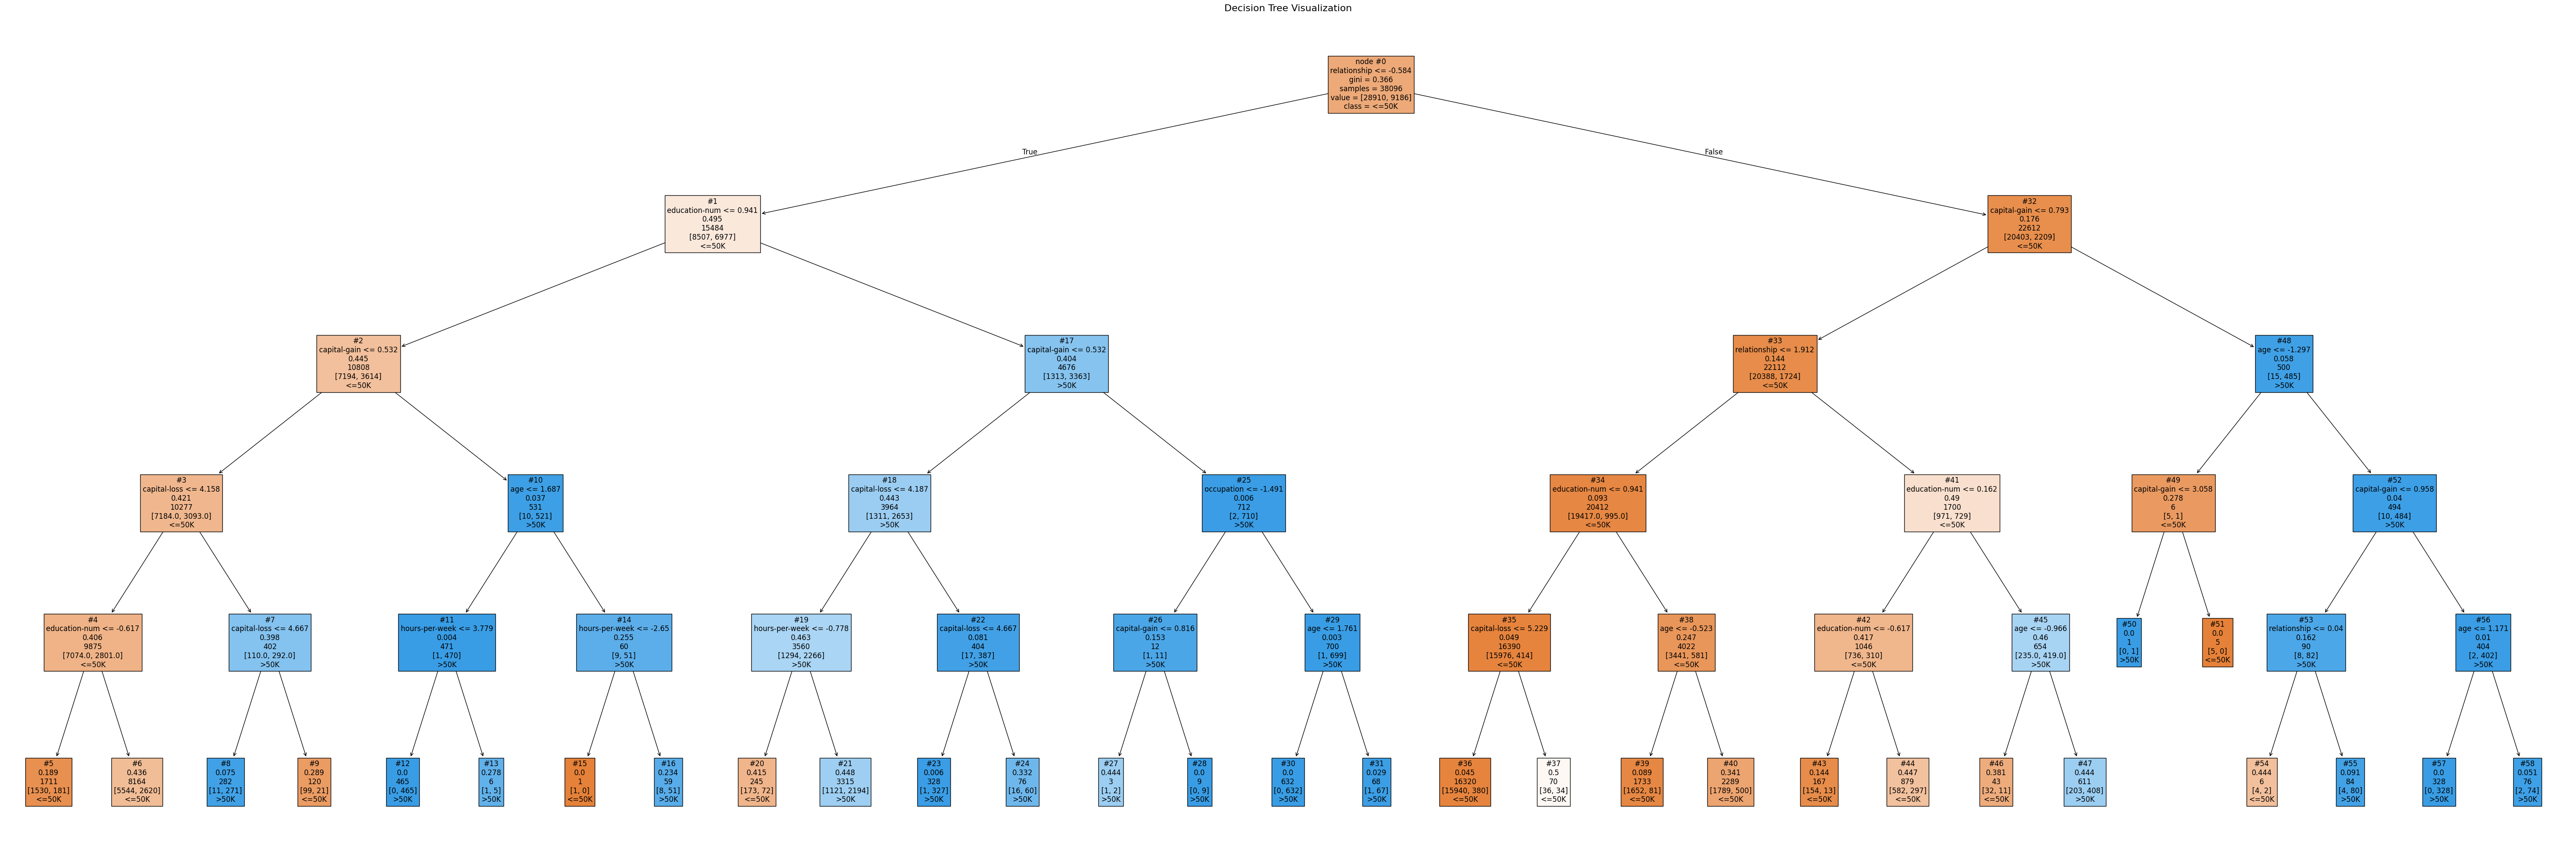

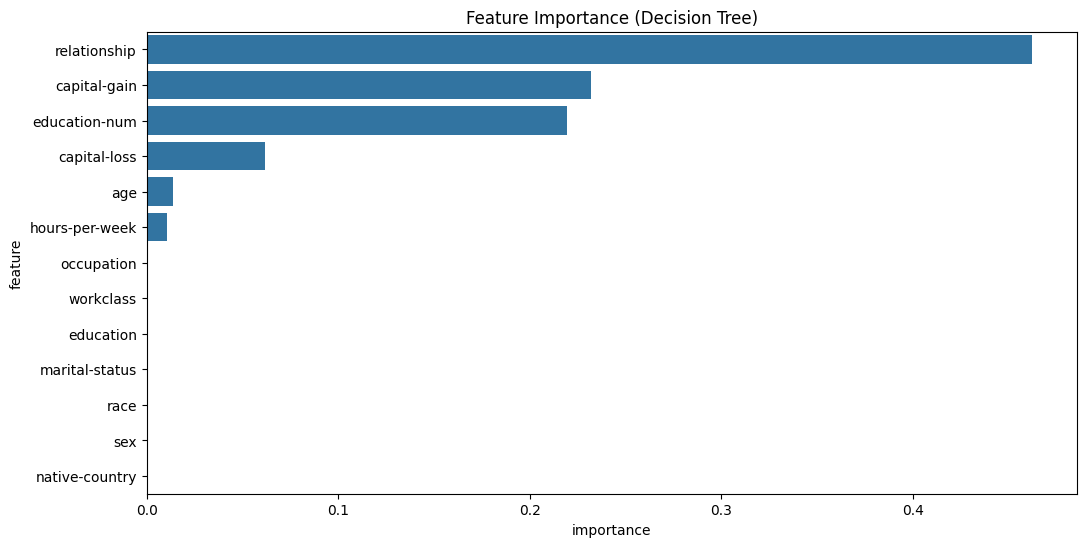

In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train and evaluate decision tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_accuracy = evaluate_model(dt, X_train_scaled, X_test_scaled, y_train, y_test, 'Decision Tree')

# Get feature names as list
feature_names = list(X.columns)

# Get unique classes in the correct order
class_names = sorted(df['income'].unique().tolist())

# Visualize the decision tree
plt.figure(figsize=(60, 20))
plot_tree(dt,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=False,  # Use rectangular boxes
          proportion=False,  # Show counts instead of proportions
          precision=3,  # Number of decimal places for numbers
          fontsize=12,
          impurity=True,  # Show entropy/gini values
          node_ids=True,  # Show node numbers
          label='root')  # Label for root node

plt.title('Decision Tree Visualization', fontsize=16)
plt.tight_layout()
plt.show()

# Feature importance
plt.figure(figsize=(12, 6))
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': dt.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance (Decision Tree)')
plt.show()

### 4. Ensemble Learning
Implemention of Random Forest and Gradient Boosting classifiers.

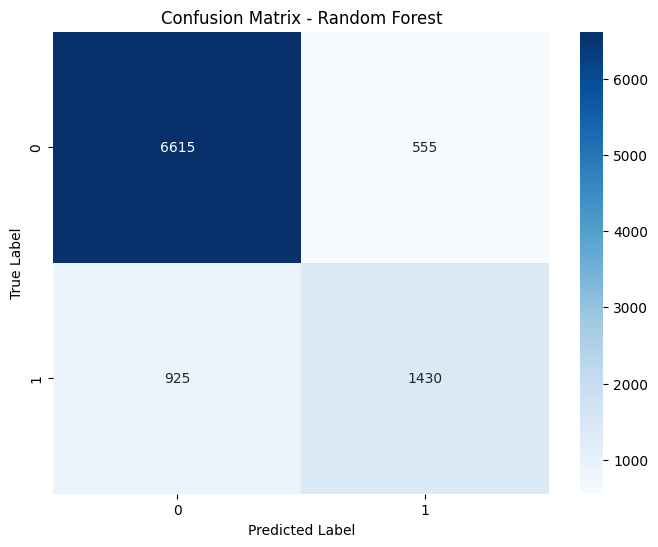


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      7170
           1       0.72      0.61      0.66      2355

    accuracy                           0.84      9525
   macro avg       0.80      0.76      0.78      9525
weighted avg       0.84      0.84      0.84      9525


Cross-validation scores: [0.84868766 0.84459903 0.85063657 0.84958656 0.84617404]
Average CV score: 0.848 (+/- 0.004)


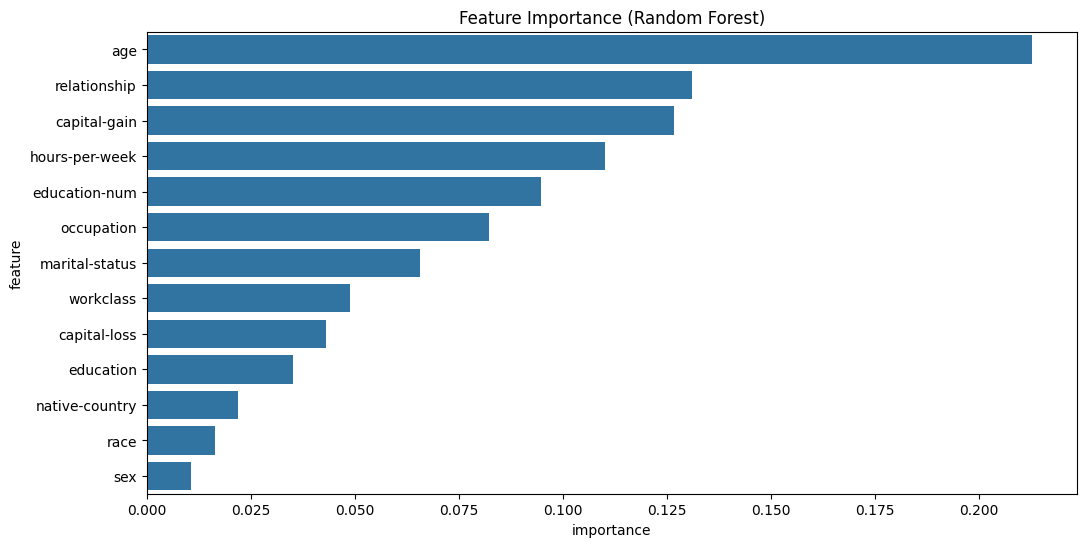

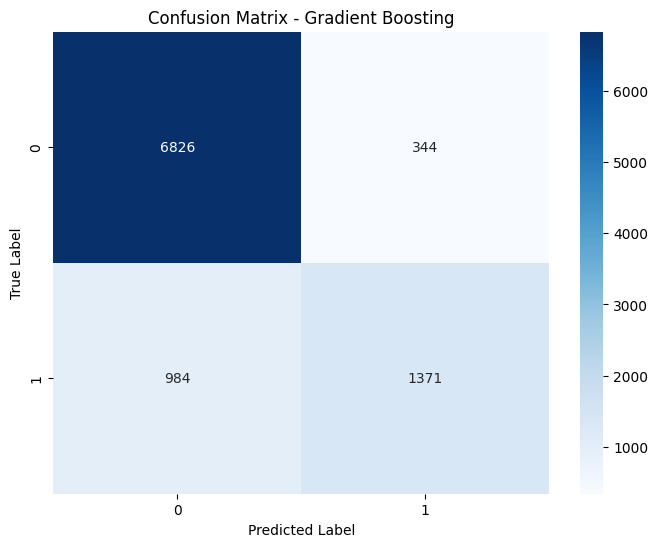


Classification Report - Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      7170
           1       0.80      0.58      0.67      2355

    accuracy                           0.86      9525
   macro avg       0.84      0.77      0.79      9525
weighted avg       0.86      0.86      0.85      9525


Cross-validation scores: [0.86706037 0.8641554  0.86743667 0.86087413 0.86664917]
Average CV score: 0.865 (+/- 0.005)


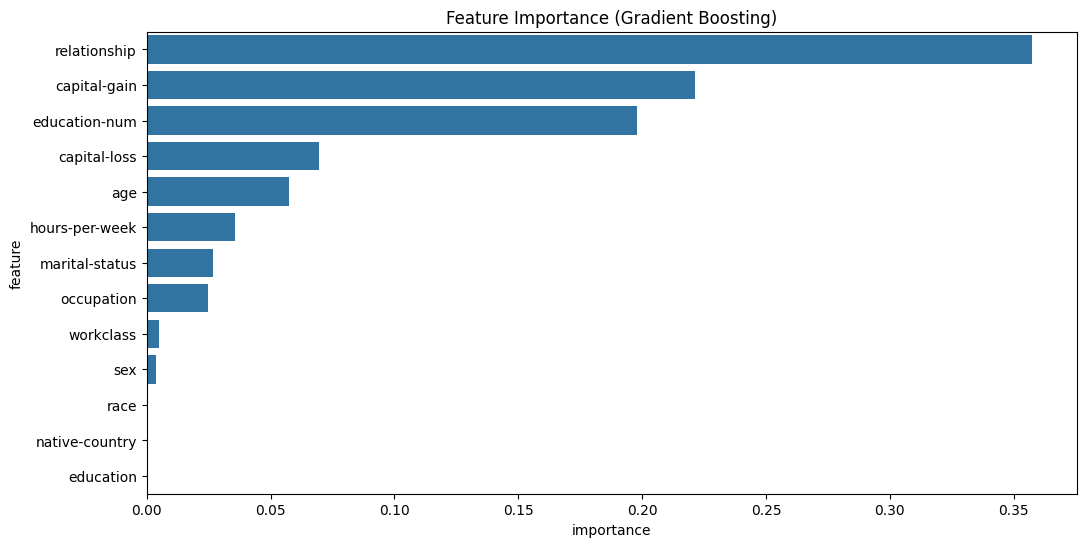

In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_accuracy = evaluate_model(rf, X_train_scaled, X_test_scaled, y_train, y_test, 'Random Forest')

# Feature importance for Random Forest
plt.figure(figsize=(12, 6))
feature_importance_rf = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values('importance', ascending=False)
sns.barplot(data=feature_importance_rf, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.show()

# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_accuracy = evaluate_model(gbc, X_train_scaled, X_test_scaled, y_train, y_test, 'Gradient Boosting')

# Feature importance for Gradient Boosting
plt.figure(figsize=(12, 6))
feature_importance_gbc = pd.DataFrame({'feature': X.columns, 'importance': gbc.feature_importances_})
feature_importance_gbc = feature_importance_gbc.sort_values('importance', ascending=False)
sns.barplot(data=feature_importance_gbc, x='importance', y='feature')
plt.title('Feature Importance (Gradient Boosting)')
plt.show()

### 5. Naive Bayes
Implement of Gaussian Naive Bayes classifier.

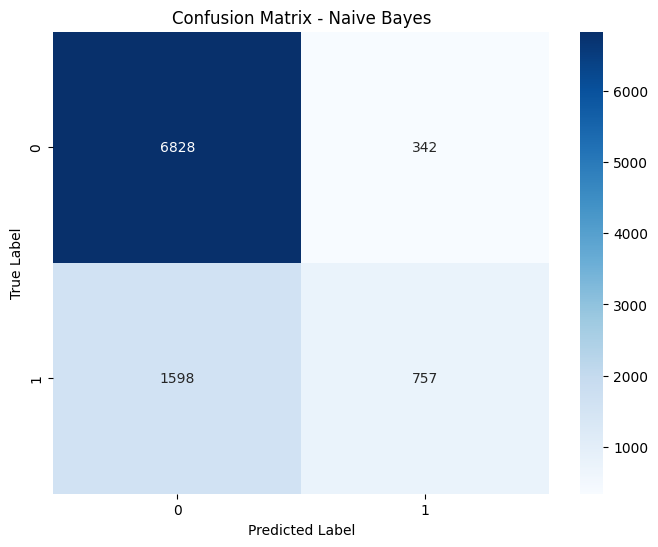


Classification Report - Naive Bayes
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      7170
           1       0.69      0.32      0.44      2355

    accuracy                           0.80      9525
   macro avg       0.75      0.64      0.66      9525
weighted avg       0.78      0.80      0.77      9525


Cross-validation scores: [0.80091864 0.79892374 0.80469878 0.79971125 0.80666754]
Average CV score: 0.802 (+/- 0.006)


In [25]:
from sklearn.naive_bayes import GaussianNB

# Train and evaluate Naive Bayes
nb = GaussianNB()
nb_accuracy = evaluate_model(nb, X_train_scaled, X_test_scaled, y_train, y_test, 'Naive Bayes')

### 6. Dimensionality Reduction
Implement of PCA and SVD, and then train models on the reduced features.

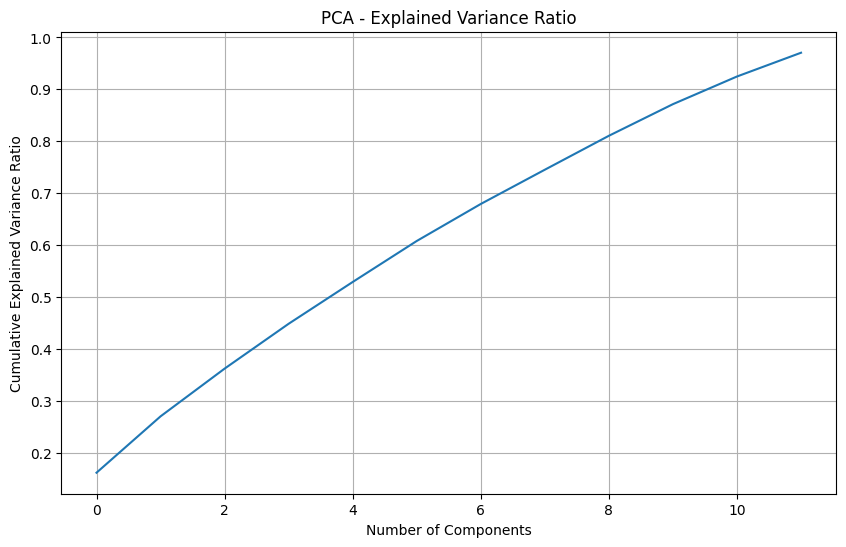

Number of components selected: 12


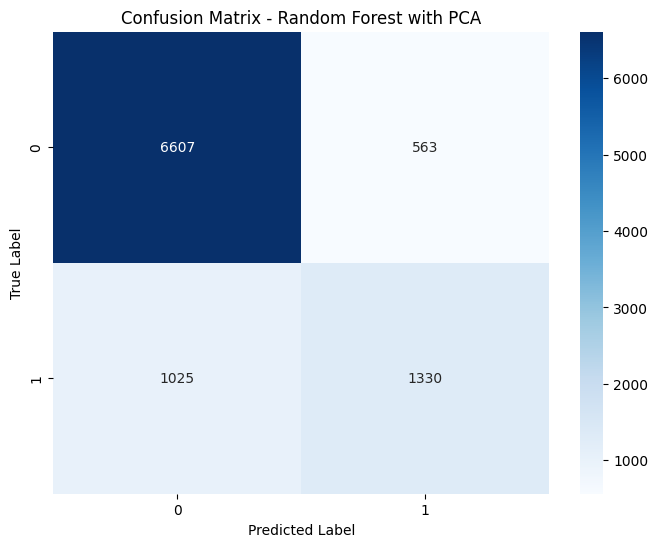


Classification Report - Random Forest with PCA
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      7170
           1       0.70      0.56      0.63      2355

    accuracy                           0.83      9525
   macro avg       0.78      0.74      0.76      9525
weighted avg       0.83      0.83      0.83      9525


Cross-validation scores: [0.83937008 0.83528022 0.83475522 0.83633023 0.840399  ]
Average CV score: 0.837 (+/- 0.005)


In [26]:
from sklearn.decomposition import PCA, TruncatedSVD

# PCA
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA - Explained Variance Ratio')
plt.grid(True)
plt.show()

print(f'Number of components selected: {pca.n_components_}')

# Train Random Forest on PCA-reduced features
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca_accuracy = evaluate_model(rf_pca, X_train_pca, X_test_pca, y_train, y_test, 'Random Forest with PCA')

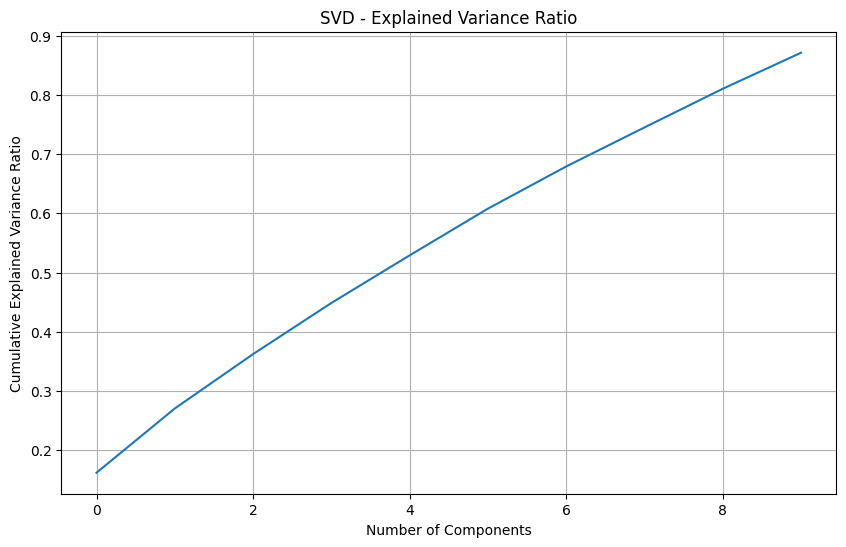

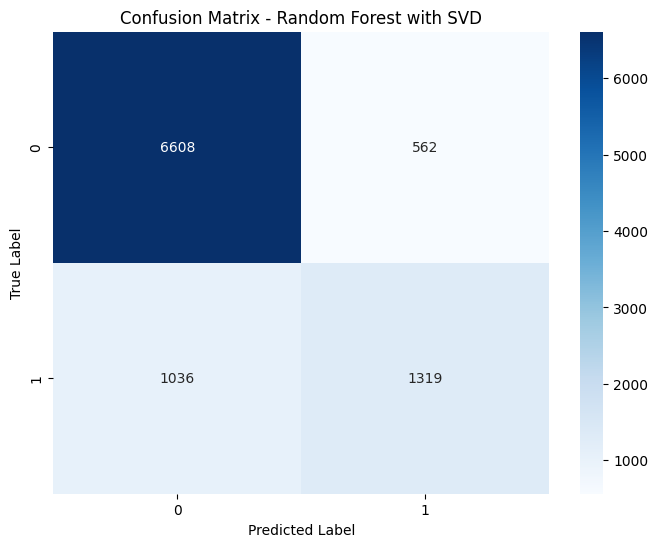


Classification Report - Random Forest with SVD
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      7170
           1       0.70      0.56      0.62      2355

    accuracy                           0.83      9525
   macro avg       0.78      0.74      0.76      9525
weighted avg       0.82      0.83      0.83      9525


Cross-validation scores: [0.83923885 0.83357396 0.83344271 0.83199895 0.839349  ]
Average CV score: 0.836 (+/- 0.006)


In [27]:
# SVD
svd = TruncatedSVD(n_components=10, random_state=42)
X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(svd.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('SVD - Explained Variance Ratio')
plt.grid(True)
plt.show()

# Train Random Forest on SVD-reduced features
rf_svd = RandomForestClassifier(n_estimators=100, random_state=42)
rf_svd_accuracy = evaluate_model(rf_svd, X_train_svd, X_test_svd, y_train, y_test, 'Random Forest with SVD')

### Model Comparison
Comparison  of the performance of all models.

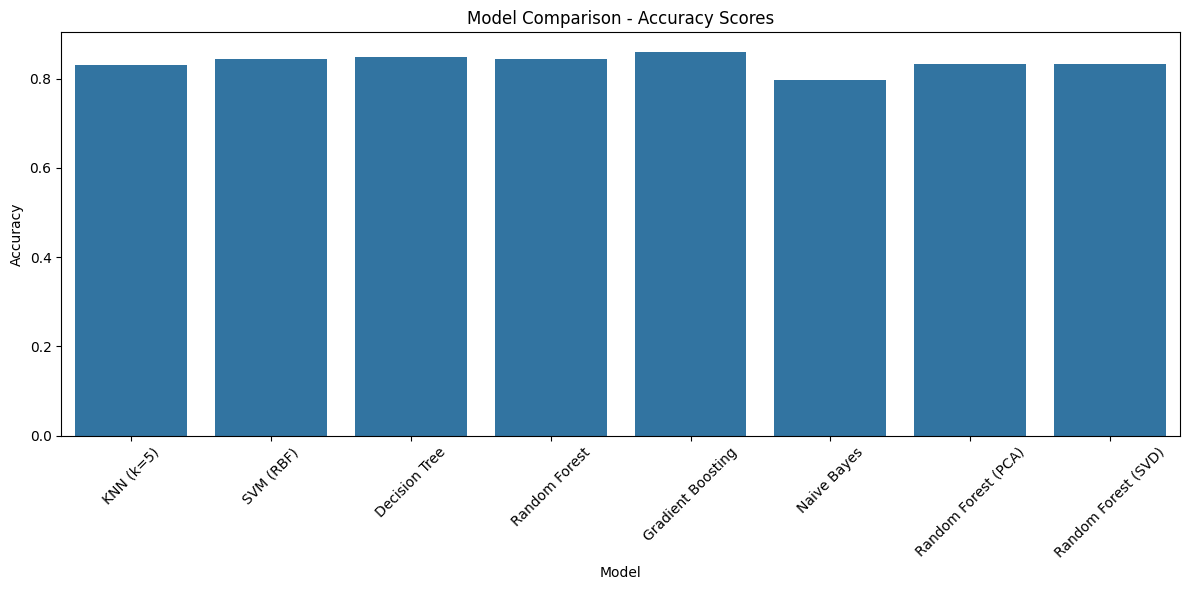

In [32]:
# Create a dictionary of model accuracies
model_accuracies = {
    'KNN (k=5)': knn_scores[1],  # Using k=5 as reference
    'SVM (RBF)': svm_scores[0],
    'Decision Tree': dt_accuracy,
    'Random Forest': rf_accuracy,
    'Gradient Boosting': gbc_accuracy,
    'Naive Bayes': nb_accuracy,
    'Random Forest (PCA)': rf_pca_accuracy,
    'Random Forest (SVD)': rf_svd_accuracy
}

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()))
plt.xticks(rotation=45)
plt.title('Model Comparison - Accuracy Scores')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

### 7. Unsupervised Learning
Applying K-Means and Hierarchical clustering with optimal cluster selection.

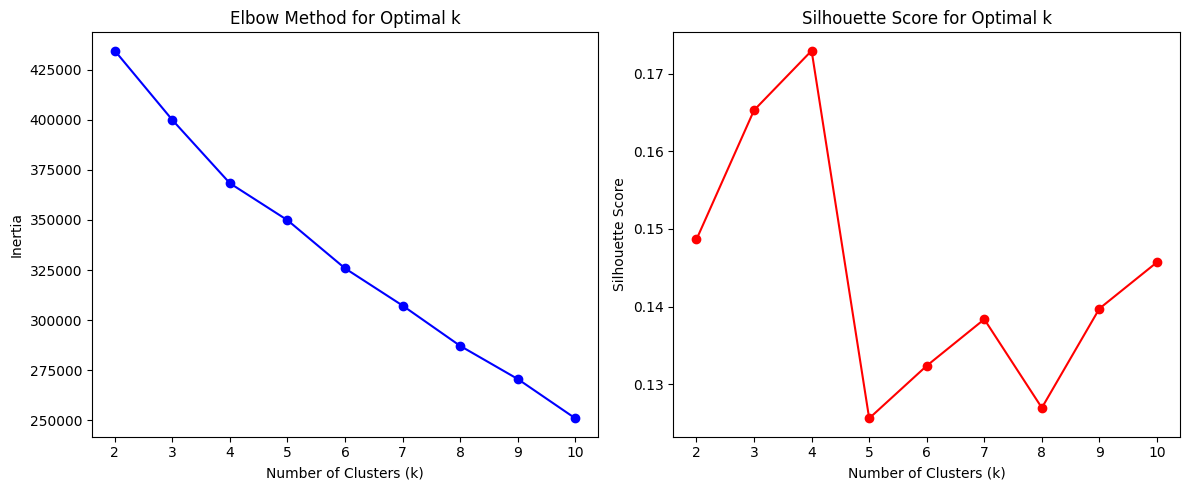


Optimal number of clusters: 4


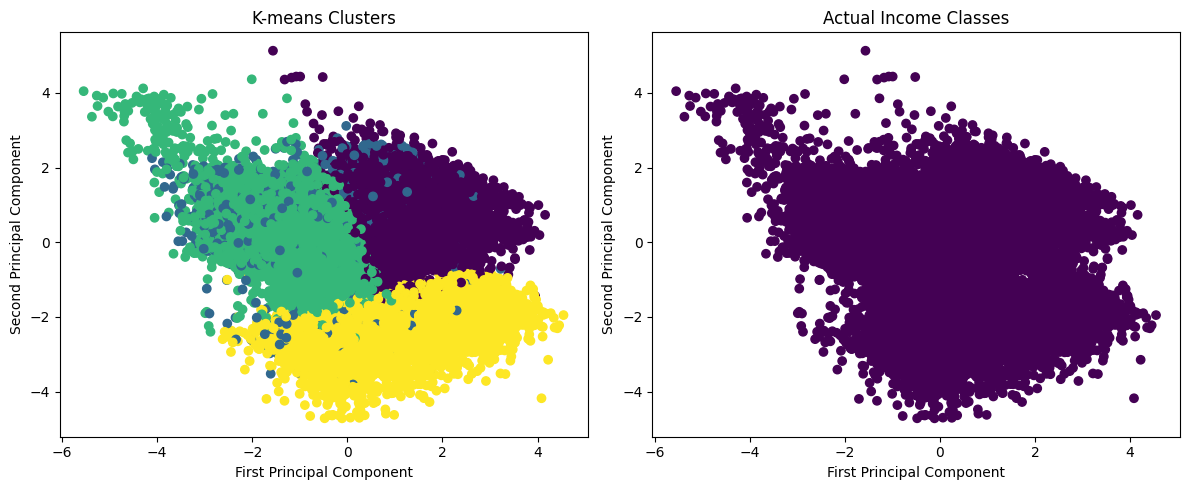


Cluster composition with income classes:
income      0     1
row_0              
0       11831  1170
1         851   915
2       11681  6838
3        4547   263

Percentage distribution of income classes in clusters:
income          0          1
row_0                       
0       91.000692   8.999308
1       48.187995  51.812005
2       63.075760  36.924240
3       94.532225   5.467775


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

# Plot elbow curve
plt.figure(figsize=(12, 5))

# Inertia plot
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Silhouette score plot
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')

plt.tight_layout()
plt.show()

# Apply K-means with optimal k
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f'\nOptimal number of clusters: {optimal_k}')

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_train_scaled)

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Plot clusters
plt.figure(figsize=(12, 5))

# Plot clusters
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.title('K-means Clusters')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Plot actual income classes
income_numeric = (y_train == '>50K').astype(int)
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=income_numeric, cmap='viridis')
plt.title('Actual Income Classes')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

plt.tight_layout()
plt.show()

# Analyze cluster composition
cluster_income_distribution = pd.crosstab(cluster_labels, y_train)
print('\nCluster composition with income classes:')
print(cluster_income_distribution)

# Calculate the percentage of each income class in clusters
cluster_percentages = cluster_income_distribution.div(cluster_income_distribution.sum(axis=1), axis=0) * 100
print('\nPercentage distribution of income classes in clusters:')
print(cluster_percentages)

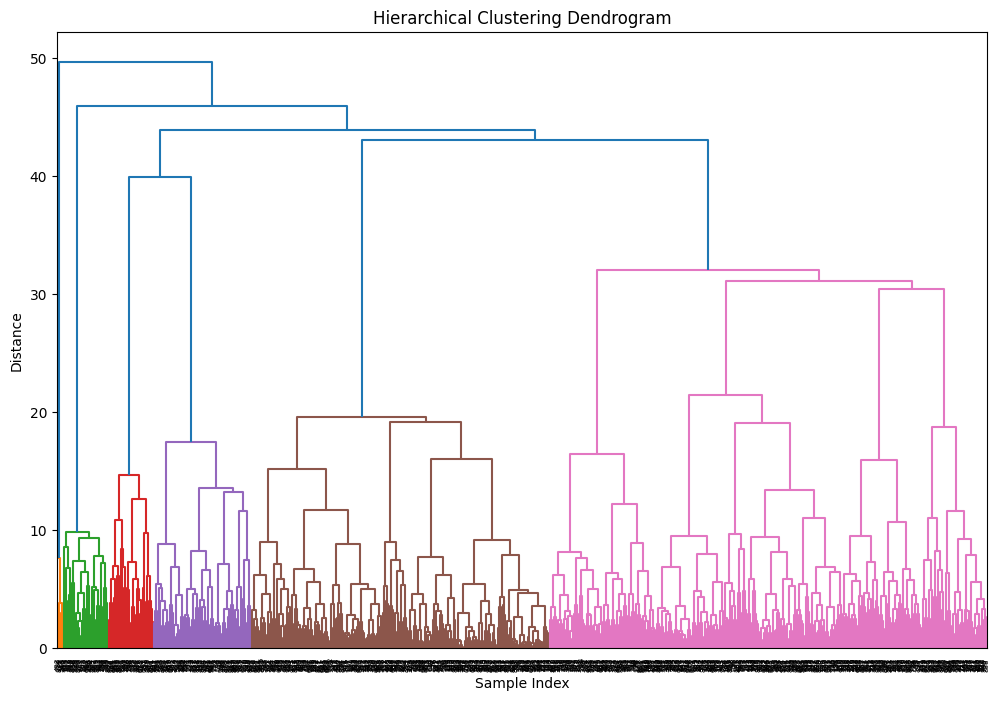

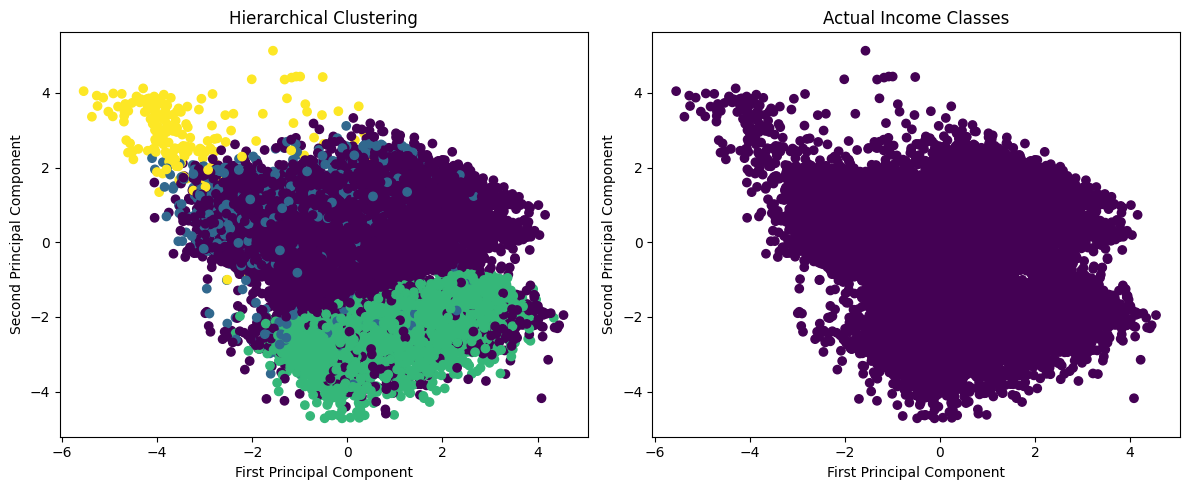


Hierarchical cluster composition with income classes:
income      0     1
row_0              
0       23951  7838
1         858   915
2        4101   239
3           0   194

Percentage distribution of income classes in hierarchical clusters:
income          0           1
row_0                        
0       75.343672   24.656328
1       48.392555   51.607445
2       94.493088    5.506912
3        0.000000  100.000000

Silhouette Scores:
K-means clustering: 0.173
Hierarchical clustering: 0.198


In [30]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Create a sample of data for visualization (using 1000 samples for better visualization)
random_indices = np.random.choice(len(X_train_scaled), size=1000, replace=False)
X_sample = X_train_scaled[random_indices]
y_sample = y_train.iloc[random_indices]

# Create linkage matrix for dendrogram
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Apply Hierarchical clustering with the same optimal number of clusters as K-means
hc = AgglomerativeClustering(n_clusters=optimal_k)
hc_labels = hc.fit_predict(X_train_scaled)

# Reduce dimensionality for visualization
X_pca_full = pca.transform(X_train_scaled)

# Plot clusters
plt.figure(figsize=(12, 5))

# Plot hierarchical clusters
plt.subplot(1, 2, 1)
plt.scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=hc_labels, cmap='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Plot actual income classes
income_numeric = (y_train == '>50K').astype(int)
plt.subplot(1, 2, 2)
plt.scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=income_numeric, cmap='viridis')
plt.title('Actual Income Classes')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

plt.tight_layout()
plt.show()

# Analyze hierarchical cluster composition
hc_income_distribution = pd.crosstab(hc_labels, y_train)
print('\nHierarchical cluster composition with income classes:')
print(hc_income_distribution)

# Calculate the percentage of each income class in hierarchical clusters
hc_percentages = hc_income_distribution.div(hc_income_distribution.sum(axis=1), axis=0) * 100
print('\nPercentage distribution of income classes in hierarchical clusters:')
print(hc_percentages)

# Compare clustering methods
print('\nSilhouette Scores:')
print(f'K-means clustering: {silhouette_score(X_train_scaled, cluster_labels):.3f}')
print(f'Hierarchical clustering: {silhouette_score(X_train_scaled, hc_labels):.3f}')

# Summary and Conclusions

1. **Supervised Learning Results:**
   - Implemented various classification algorithms to predict income levels
   - Compared performance using accuracy, precision, recall, and F1-score
   - Used cross-validation to ensure robust model evaluation

2. **Feature Importance:**
   - Analyzed important features using Decision Trees and Random Forest
   - Identified key factors affecting income prediction

3. **Dimensionality Reduction:**
   - Applied PCA and SVD to reduce feature dimensionality
   - Evaluated model performance on reduced features

4. **Unsupervised Learning Insights:**
   - Used K-Means and Hierarchical clustering to identify patterns
   - Analyzed cluster characteristics and their relationship with income levels